# M5 Three-Class Model Training and Comparison

This notebook trains CatBoost, XGBoost, and an FT-Transformer-style attention model for `NO_INJURY`, `MINOR_INJURY`, and `SEVERE_INJURY`. The processed 20% stratified test set is used only for final reporting; validation is created inside the 80% training set.

In [ ]:
# Run once if the environment does not already contain these packages.
%pip install -q pandas numpy scikit-learn catboost xgboost torch matplotlib joblib

In [13]:
from pathlib import Path
import copy
import json
import random
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from catboost import CatBoostClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
FAST_RUN = False       # Set True for a quick pipeline test before full training.
USE_GPU_FOR_BOOSTING = False  # Set True only when CatBoost/XGBoost GPU support is configured.
WEIGHT_ALPHAS = [0.5, 0.75, 1.0]
CALIBRATION_MULTIPLIERS = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "processed" / "M5" / "preprocessing_metadata.json").exists():
            return candidate
    raise FileNotFoundError("Cannot find data/processed/M5/preprocessing_metadata.json")

ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "processed" / "M5"
OUTPUT_DIR = ROOT / "M5" / "model_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with (DATA_DIR / "preprocessing_metadata.json").open(encoding="utf-8") as file:
    META = json.load(file)

TARGET = META["target"]
TARGET_ENCODED = f"{TARGET}_encoded"
CAT_COLS = META["categorical_features"]
NUM_COLS = META["numeric_features"]
MODEL_FEATURES = META["model_features"]
TARGET_MAPPING = META["target_mapping"]
ID_TO_LABEL = {value: key for key, value in TARGET_MAPPING.items()}
LABEL_IDS = sorted(ID_TO_LABEL)
CLASS_NAMES = [ID_TO_LABEL[index] for index in LABEL_IDS]
N_CLASSES = len(CLASS_NAMES)

full_train_tab = pd.read_csv(DATA_DIR / "train_tabular.csv")
test_tab = pd.read_csv(DATA_DIR / "test_tabular.csv")
full_train_ohe = pd.read_csv(DATA_DIR / "train_onehot.csv")
test_ohe = pd.read_csv(DATA_DIR / "test_onehot.csv")

# The external 20% test set remains untouched. This internal stratified split is
# used only for early stopping, weight selection, and probability calibration.
development_indices, validation_indices = train_test_split(
    np.arange(len(full_train_tab)),
    test_size=0.20,
    random_state=SEED,
    stratify=full_train_tab[TARGET_ENCODED],
)
train_tab = full_train_tab.iloc[development_indices].reset_index(drop=True)
valid_tab = full_train_tab.iloc[validation_indices].reset_index(drop=True)
train_ohe = full_train_ohe.iloc[development_indices].reset_index(drop=True)
valid_ohe = full_train_ohe.iloc[validation_indices].reset_index(drop=True)

if FAST_RUN:
    def stratified_sample_pair(tabular, onehot, n_rows):
        if len(tabular) <= n_rows:
            return tabular.reset_index(drop=True), onehot.reset_index(drop=True)
        selected, _ = train_test_split(
            np.arange(len(tabular)), train_size=n_rows, random_state=SEED,
            stratify=tabular[TARGET_ENCODED],
        )
        return tabular.iloc[selected].reset_index(drop=True), onehot.iloc[selected].reset_index(drop=True)
    train_tab, train_ohe = stratified_sample_pair(train_tab, train_ohe, 30000)
    valid_tab, valid_ohe = stratified_sample_pair(valid_tab, valid_ohe, 8000)
    test_tab, test_ohe = stratified_sample_pair(test_tab, test_ohe, 8000)

y_train = train_tab[TARGET_ENCODED].to_numpy(dtype=np.int64)
y_valid = valid_tab[TARGET_ENCODED].to_numpy(dtype=np.int64)
y_test = test_tab[TARGET_ENCODED].to_numpy(dtype=np.int64)

# Balanced weights are softened with an exponent selected on validation Macro F1.
class_counts = np.bincount(y_train, minlength=N_CLASSES)
balanced_class_weights = len(y_train) / (N_CLASSES * class_counts)

def weights_for_alpha(alpha):
    weights = balanced_class_weights ** alpha
    return weights / weights.mean()

print("Device for FT-Transformer:", "cuda" if torch.cuda.is_available() else "cpu")
print("Rows:", {"train": len(y_train), "valid": len(y_valid), "test": len(y_test)})
print("Weight-search exponents:", WEIGHT_ALPHAS)
print("Fully balanced weights:", dict(zip(CLASS_NAMES, balanced_class_weights.round(3))))
print("Outputs:", OUTPUT_DIR)

Device for FT-Transformer: cuda
Rows: {'train': 133936, 'valid': 33484, 'test': 41855}
Weight-search exponents: [0.5, 0.75, 1.0]
Fully balanced weights: {'NO_INJURY': np.float64(0.451), 'MINOR_INJURY': np.float64(1.466), 'SEVERE_INJURY': np.float64(10.089)}
Outputs: D:\Code\LZU-INFO442-Traffic-Accident-Severity-Prediction\M5\model_outputs


In [14]:
def metric_row(model_name, split_name, y_true, y_pred, training_seconds):
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "training_seconds": training_seconds,
    }

def adjusted_predictions(probabilities, multipliers):
    adjusted = probabilities * np.asarray(multipliers, dtype=np.float64)
    return adjusted.argmax(axis=1)

def optimize_probability_multipliers(y_true, probabilities):
    # Class 0 is the reference. Other multipliers are coordinate-searched in a bounded range.
    multipliers = np.ones(N_CLASSES, dtype=np.float64)
    best_pred = adjusted_predictions(probabilities, multipliers)
    best_score = f1_score(y_true, best_pred, average="macro", zero_division=0)
    for _ in range(3):
        improved = False
        for class_id in range(1, N_CLASSES):
            local_best_value = multipliers[class_id]
            local_best_score = best_score
            for candidate in CALIBRATION_MULTIPLIERS:
                trial = multipliers.copy()
                trial[class_id] = candidate
                prediction = adjusted_predictions(probabilities, trial)
                score = f1_score(y_true, prediction, average="macro", zero_division=0)
                if score > local_best_score + 1e-6:
                    local_best_score = score
                    local_best_value = candidate
            if local_best_value != multipliers[class_id]:
                multipliers[class_id] = local_best_value
                best_score = local_best_score
                improved = True
        if not improved:
            break
    return multipliers, best_score

def choose_weight_trial(trials):
    return max(trials, key=lambda item: item["validation_macro_f1"])

def save_detailed_results(model_name, split_name, y_true, y_pred, y_proba=None):
    report = classification_report(
        y_true,
        y_pred,
        labels=LABEL_IDS,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(OUTPUT_DIR / f"{model_name}_{split_name}_classification_report.csv")

    predictions = pd.DataFrame({
        "actual_encoded": y_true,
        "predicted_encoded": y_pred,
        "actual_label": [ID_TO_LABEL[int(value)] for value in y_true],
        "predicted_label": [ID_TO_LABEL[int(value)] for value in y_pred],
    })
    if y_proba is not None:
        for class_id, class_name in enumerate(CLASS_NAMES):
            predictions[f"probability_{class_name}"] = y_proba[:, class_id]
    predictions.to_csv(OUTPUT_DIR / f"{model_name}_{split_name}_predictions.csv", index=False)

def plot_confusion_matrices(results):
    fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 6))
    axes = np.atleast_1d(axes)
    for axis, (model_name, result) in zip(axes, results.items()):
        matrix = confusion_matrix(result["y_true"], result["y_pred"], labels=LABEL_IDS, normalize="true")
        ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES).plot(
            ax=axis, cmap="Blues", values_format=".2f", colorbar=False
        )
        axis.set_title(f"{model_name} – normalized test matrix")
        axis.tick_params(axis="x", rotation=75)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "test_confusion_matrices.png", dpi=180, bbox_inches="tight")
    plt.show()

metric_rows = []
test_results = {}

## 1. CatBoost

CatBoost consumes the categorical table directly and does not require one-hot encoding.

In [15]:
catboost_trials = []
catboost_total_seconds = 0.0
for alpha in WEIGHT_ALPHAS:
    trial_weights = weights_for_alpha(alpha)
    model = CatBoostClassifier(
        iterations=250 if FAST_RUN else 1600,
        depth=8,
        learning_rate=0.06,
        loss_function="MultiClass",
        eval_metric="TotalF1:average=Macro",
        class_weights=trial_weights.tolist(),
        random_seed=SEED,
        l2_leaf_reg=5,
        random_strength=0.5,
        od_type="Iter",
        od_wait=100,
        verbose=200,
        allow_writing_files=False,
        task_type="GPU" if USE_GPU_FOR_BOOSTING else "CPU",
    )
    start = time.perf_counter()
    model.fit(
        train_tab[MODEL_FEATURES], y_train, cat_features=CAT_COLS,
        eval_set=(valid_tab[MODEL_FEATURES], y_valid), use_best_model=True,
    )
    elapsed = time.perf_counter() - start
    catboost_total_seconds += elapsed
    valid_proba = model.predict_proba(valid_tab[MODEL_FEATURES])
    valid_pred = valid_proba.argmax(axis=1)
    score = f1_score(y_valid, valid_pred, average="macro", zero_division=0)
    catboost_trials.append({
        "alpha": alpha, "model": model, "validation_proba": valid_proba,
        "validation_macro_f1": score, "seconds": elapsed,
    })
    print(f"CatBoost alpha={alpha:.2f} | validation Macro F1={score:.4f}")

catboost_best = choose_weight_trial(catboost_trials)
catboost_model = catboost_best["model"]
catboost_valid_proba = catboost_best["validation_proba"]
catboost_valid_raw = catboost_valid_proba.argmax(axis=1)
catboost_multipliers, _ = optimize_probability_multipliers(y_valid, catboost_valid_proba)
catboost_valid_cal = adjusted_predictions(catboost_valid_proba, catboost_multipliers)
catboost_test_proba = catboost_model.predict_proba(test_tab[MODEL_FEATURES])
catboost_test_raw = catboost_test_proba.argmax(axis=1)
catboost_test_cal = adjusted_predictions(catboost_test_proba, catboost_multipliers)

metric_rows.append(metric_row("CatBoost raw", "validation", y_valid, catboost_valid_raw, catboost_total_seconds))
metric_rows.append(metric_row("CatBoost calibrated", "validation", y_valid, catboost_valid_cal, catboost_total_seconds))
metric_rows.append(metric_row("CatBoost raw", "test", y_test, catboost_test_raw, catboost_total_seconds))
metric_rows.append(metric_row("CatBoost calibrated", "test", y_test, catboost_test_cal, catboost_total_seconds))
test_results["CatBoost calibrated"] = {"y_true": y_test, "y_pred": catboost_test_cal}
save_detailed_results("catboost_calibrated", "test", y_test, catboost_test_cal, catboost_test_proba)
catboost_model.save_model(OUTPUT_DIR / "catboost_model.cbm")
print("Selected CatBoost alpha:", catboost_best["alpha"], "multipliers:", catboost_multipliers)

catboost_importance = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "importance": catboost_model.get_feature_importance(),
}).sort_values("importance", ascending=False)
catboost_importance.to_csv(OUTPUT_DIR / "catboost_feature_importance.csv", index=False)
catboost_importance.head(15)

0:	learn: 0.3854311	test: 0.3885962	best: 0.3885962 (0)	total: 371ms	remaining: 9m 52s
200:	learn: 0.4600732	test: 0.4251886	best: 0.4256832 (179)	total: 1m 43s	remaining: 11m 56s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4287214691
bestIteration = 291

Shrink model to first 292 iterations.
CatBoost alpha=0.50 | validation Macro F1=0.4554
0:	learn: 0.4320936	test: 0.4359539	best: 0.4359539 (0)	total: 325ms	remaining: 8m 39s
200:	learn: 0.5429822	test: 0.4687500	best: 0.4708319 (166)	total: 1m 44s	remaining: 12m 10s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4709304592
bestIteration = 235

Shrink model to first 236 iterations.
CatBoost alpha=0.75 | validation Macro F1=0.4753
0:	learn: 0.4854325	test: 0.4829197	best: 0.4829197 (0)	total: 339ms	remaining: 9m 2s
200:	learn: 0.5676980	test: 0.4959075	best: 0.4997610 (156)	total: 1m 59s	remaining: 13m 52s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4997610372
bestI

,feature,importance
3,first_crash_type,30.911235
9,prim_contributory_cause,13.221316
4,trafficway_type,8.325968
10,num_units,7.102783
0,traffic_control_device,5.506124
6,roadway_surface_cond,4.153795
17,hour_cos,3.438798
7,road_defect,3.404200
2,lighting_condition,2.946999
21,month_cos,2.842978


## 2. XGBoost

XGBoost uses the leakage-safe one-hot files. Training rows receive the same sqrt-balanced class weighting strategy.

In [16]:
OHE_FEATURES = [column for column in train_ohe.columns if column != TARGET_ENCODED]
X_train_ohe = train_ohe[OHE_FEATURES]
X_valid_ohe = valid_ohe[OHE_FEATURES]
X_test_ohe = test_ohe[OHE_FEATURES]

xgboost_trials = []
xgboost_total_seconds = 0.0
for alpha in WEIGHT_ALPHAS:
    trial_weights = weights_for_alpha(alpha)
    model = XGBClassifier(
        objective="multi:softprob", num_class=N_CLASSES,
        n_estimators=250 if FAST_RUN else 1400, learning_rate=0.04,
        max_depth=8, min_child_weight=3, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=2.0, gamma=0.05,
        eval_metric="mlogloss", early_stopping_rounds=100,
        tree_method="hist", device="cuda" if USE_GPU_FOR_BOOSTING else "cpu",
        random_state=SEED, n_jobs=-1,
    )
    start = time.perf_counter()
    model.fit(
        X_train_ohe, y_train, sample_weight=trial_weights[y_train],
        eval_set=[(X_valid_ohe, y_valid)], verbose=200,
    )
    elapsed = time.perf_counter() - start
    xgboost_total_seconds += elapsed
    valid_proba = model.predict_proba(X_valid_ohe)
    valid_pred = valid_proba.argmax(axis=1)
    score = f1_score(y_valid, valid_pred, average="macro", zero_division=0)
    xgboost_trials.append({
        "alpha": alpha, "model": model, "validation_proba": valid_proba,
        "validation_macro_f1": score, "seconds": elapsed,
    })
    print(f"XGBoost alpha={alpha:.2f} | validation Macro F1={score:.4f}")

xgboost_best = choose_weight_trial(xgboost_trials)
xgboost_model = xgboost_best["model"]
xgboost_valid_proba = xgboost_best["validation_proba"]
xgboost_valid_raw = xgboost_valid_proba.argmax(axis=1)
xgboost_multipliers, _ = optimize_probability_multipliers(y_valid, xgboost_valid_proba)
xgboost_valid_cal = adjusted_predictions(xgboost_valid_proba, xgboost_multipliers)
xgboost_test_proba = xgboost_model.predict_proba(X_test_ohe)
xgboost_test_raw = xgboost_test_proba.argmax(axis=1)
xgboost_test_cal = adjusted_predictions(xgboost_test_proba, xgboost_multipliers)

metric_rows.append(metric_row("XGBoost raw", "validation", y_valid, xgboost_valid_raw, xgboost_total_seconds))
metric_rows.append(metric_row("XGBoost calibrated", "validation", y_valid, xgboost_valid_cal, xgboost_total_seconds))
metric_rows.append(metric_row("XGBoost raw", "test", y_test, xgboost_test_raw, xgboost_total_seconds))
metric_rows.append(metric_row("XGBoost calibrated", "test", y_test, xgboost_test_cal, xgboost_total_seconds))
test_results["XGBoost calibrated"] = {"y_true": y_test, "y_pred": xgboost_test_cal}
save_detailed_results("xgboost_calibrated", "test", y_test, xgboost_test_cal, xgboost_test_proba)
xgboost_model.save_model(OUTPUT_DIR / "xgboost_model.json")
print("Selected XGBoost alpha:", xgboost_best["alpha"], "multipliers:", xgboost_multipliers)

xgboost_importance = pd.DataFrame({
    "feature": OHE_FEATURES,
    "importance": xgboost_model.feature_importances_,
}).sort_values("importance", ascending=False)
xgboost_importance.to_csv(OUTPUT_DIR / "xgboost_feature_importance.csv", index=False)
xgboost_importance.head(15)

[0]	validation_0-mlogloss:0.94064
[200]	validation_0-mlogloss:0.62864
[400]	validation_0-mlogloss:0.62595
[600]	validation_0-mlogloss:0.62482
[800]	validation_0-mlogloss:0.62385
[1000]	validation_0-mlogloss:0.62339
[1200]	validation_0-mlogloss:0.62324
[1283]	validation_0-mlogloss:0.62328
XGBoost alpha=0.50 | validation Macro F1=0.4583
[0]	validation_0-mlogloss:1.00572
[200]	validation_0-mlogloss:0.71942
[400]	validation_0-mlogloss:0.71258
[600]	validation_0-mlogloss:0.70656
[800]	validation_0-mlogloss:0.70114
[1000]	validation_0-mlogloss:0.69669
[1200]	validation_0-mlogloss:0.69286
[1399]	validation_0-mlogloss:0.68943
XGBoost alpha=0.75 | validation Macro F1=0.4657
[0]	validation_0-mlogloss:1.08983
[200]	validation_0-mlogloss:0.86779
[400]	validation_0-mlogloss:0.85285
[600]	validation_0-mlogloss:0.83849
[800]	validation_0-mlogloss:0.82532
[1000]	validation_0-mlogloss:0.81344
[1200]	validation_0-mlogloss:0.80302
[1399]	validation_0-mlogloss:0.79419
XGBoost alpha=1.00 | validation Macro

,feature,importance
48,first_crash_type_PEDESTRIAN,0.097251
47,first_crash_type_PEDALCYCLIST,0.058002
53,first_crash_type_SIDESWIPE SAME DIRECTION,0.053664
46,first_crash_type_PARKED MOTOR VEHICLE,0.025396
115,prim_contributory_cause_IMPROPER BACKING,0.020937
0,num_units,0.017601
40,first_crash_type_ANGLE,0.017247
122,prim_contributory_cause_PHYSICAL CONDITION OF ...,0.016222
49,first_crash_type_REAR END,0.014857
101,prim_contributory_cause_DISREGARDING TRAFFIC S...,0.014078


## 3. FT-Transformer-style attention model

Each categorical feature is embedded as a token. Each numeric feature is projected into the same token space. Transformer self-attention models interactions among all feature tokens.

In [17]:
category_maps = {}
category_sizes = []
for column in CAT_COLS:
    values = sorted(train_tab[column].astype(str).unique().tolist())
    category_maps[column] = {value: index + 1 for index, value in enumerate(values)}
    category_sizes.append(len(values) + 1)  # index 0 is reserved for unseen values

numeric_scaler = StandardScaler()
numeric_scaler.fit(train_tab[NUM_COLS])

def encode_attention_inputs(frame):
    categorical = np.column_stack([
        frame[column].astype(str).map(category_maps[column]).fillna(0).to_numpy(dtype=np.int64)
        for column in CAT_COLS
    ])
    numeric = numeric_scaler.transform(frame[NUM_COLS]).astype(np.float32)
    target = frame[TARGET_ENCODED].to_numpy(dtype=np.int64)
    return categorical, numeric, target

train_cat, train_num, ft_y_train = encode_attention_inputs(train_tab)
valid_cat, valid_num, ft_y_valid = encode_attention_inputs(valid_tab)
test_cat, test_num, ft_y_test = encode_attention_inputs(test_tab)

joblib.dump(numeric_scaler, OUTPUT_DIR / "ft_numeric_scaler.joblib")
with (OUTPUT_DIR / "ft_category_maps.json").open("w", encoding="utf-8") as file:
    json.dump(category_maps, file, ensure_ascii=False, indent=2)

class TabularDataset(Dataset):
    def __init__(self, categorical, numeric, target):
        self.categorical = torch.as_tensor(categorical, dtype=torch.long)
        self.numeric = torch.as_tensor(numeric, dtype=torch.float32)
        self.target = torch.as_tensor(target, dtype=torch.long)

    def __len__(self):
        return len(self.target)

    def __getitem__(self, index):
        return self.categorical[index], self.numeric[index], self.target[index]

batch_size = 512 if FAST_RUN else 1024
train_loader = DataLoader(
    TabularDataset(train_cat, train_num, ft_y_train),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
valid_loader = DataLoader(
    TabularDataset(valid_cat, valid_num, ft_y_valid),
    batch_size=batch_size * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    TabularDataset(test_cat, test_num, ft_y_test),
    batch_size=batch_size * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

class NumericalTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias = nn.Parameter(torch.empty(n_features, d_token))
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, values):
        return values.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)

class FTTransformer(nn.Module):
    def __init__(self, category_sizes, n_numeric, n_classes, d_token=64, n_heads=8, n_layers=3, dropout=0.15):
        super().__init__()
        self.category_embeddings = nn.ModuleList([
            nn.Embedding(size, d_token) for size in category_sizes
        ])
        self.numeric_tokenizer = NumericalTokenizer(n_numeric, d_token)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        nn.init.normal_(self.cls_token, std=0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=d_token * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, d_token * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token * 2, n_classes),
        )

    def forward(self, categorical, numeric):
        categorical_tokens = torch.stack([
            embedding(categorical[:, index])
            for index, embedding in enumerate(self.category_embeddings)
        ], dim=1)
        numeric_tokens = self.numeric_tokenizer(numeric)
        cls = self.cls_token.expand(categorical.size(0), -1, -1)
        tokens = torch.cat([cls, categorical_tokens, numeric_tokens], dim=1)
        encoded = self.transformer(tokens)
        return self.head(encoded[:, 0])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0):
        super().__init__()
        self.register_buffer("class_weights", class_weights)
        self.gamma = gamma

    def forward(self, logits, target):
        log_probabilities = torch.log_softmax(logits, dim=1)
        probabilities = log_probabilities.exp()
        target_log_probability = log_probabilities.gather(1, target.unsqueeze(1)).squeeze(1)
        target_probability = probabilities.gather(1, target.unsqueeze(1)).squeeze(1)
        focal_factor = (1.0 - target_probability).pow(self.gamma)
        loss = -focal_factor * target_log_probability
        if self.class_weights is not None:
            loss = loss * self.class_weights[target]
        return loss.mean()

def build_ft_model():
    return FTTransformer(
        category_sizes=category_sizes, n_numeric=len(NUM_COLS), n_classes=N_CLASSES,
        d_token=48 if FAST_RUN else 64, n_heads=8,
        n_layers=2 if FAST_RUN else 3, dropout=0.15,
    ).to(DEVICE)

def predict_torch(model, loader):
    model.eval()
    probabilities = []
    targets = []
    with torch.no_grad():
        for categorical, numeric, target in loader:
            logits = model(categorical.to(DEVICE), numeric.to(DEVICE))
            probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())
            targets.append(target.numpy())
    probabilities = np.concatenate(probabilities)
    targets = np.concatenate(targets)
    return targets, probabilities.argmax(axis=1), probabilities

max_epochs = 5 if FAST_RUN else 30
patience = 3 if FAST_RUN else 6
ft_trials = []
ft_total_seconds = 0.0

for alpha in WEIGHT_ALPHAS:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    model = build_ft_model()
    trial_weights = torch.tensor(weights_for_alpha(alpha), dtype=torch.float32, device=DEVICE)
    criterion = FocalLoss(class_weights=trial_weights, gamma=2.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    best_macro_f1 = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []
    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0
        for categorical, numeric, target in train_loader:
            categorical = categorical.to(DEVICE, non_blocking=True)
            numeric = numeric.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(categorical, numeric)
            loss = criterion(logits, target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item() * len(target)

        _, validation_pred, validation_proba = predict_torch(model, valid_loader)
        validation_macro_f1 = f1_score(ft_y_valid, validation_pred, average="macro", zero_division=0)
        average_loss = total_loss / len(train_loader.dataset)
        scheduler.step(validation_macro_f1)
        history.append({
            "alpha": alpha, "epoch": epoch, "train_loss": average_loss,
            "validation_macro_f1": validation_macro_f1,
        })
        print(f"FT alpha={alpha:.2f} | epoch={epoch:02d} | loss={average_loss:.4f} | val_macro_f1={validation_macro_f1:.4f}")
        if validation_macro_f1 > best_macro_f1 + 1e-4:
            best_macro_f1 = validation_macro_f1
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    elapsed = time.perf_counter() - start
    ft_total_seconds += elapsed
    model.load_state_dict(best_state)
    _, _, validation_proba = predict_torch(model, valid_loader)
    ft_trials.append({
        "alpha": alpha, "state": best_state, "validation_proba": validation_proba,
        "validation_macro_f1": best_macro_f1, "history": history, "seconds": elapsed,
    })
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ft_best = choose_weight_trial(ft_trials)
ft_model = build_ft_model()
ft_model.load_state_dict(ft_best["state"])
ft_valid_proba = ft_best["validation_proba"]
ft_valid_raw = ft_valid_proba.argmax(axis=1)
ft_multipliers, _ = optimize_probability_multipliers(ft_y_valid, ft_valid_proba)
ft_valid_cal = adjusted_predictions(ft_valid_proba, ft_multipliers)
ft_test_true, ft_test_raw, ft_test_proba = predict_torch(ft_model, test_loader)
ft_test_cal = adjusted_predictions(ft_test_proba, ft_multipliers)

metric_rows.append(metric_row("FT-Transformer raw", "validation", ft_y_valid, ft_valid_raw, ft_total_seconds))
metric_rows.append(metric_row("FT-Transformer calibrated", "validation", ft_y_valid, ft_valid_cal, ft_total_seconds))
metric_rows.append(metric_row("FT-Transformer raw", "test", ft_test_true, ft_test_raw, ft_total_seconds))
metric_rows.append(metric_row("FT-Transformer calibrated", "test", ft_test_true, ft_test_cal, ft_total_seconds))
test_results["FT-Transformer calibrated"] = {"y_true": ft_test_true, "y_pred": ft_test_cal}
save_detailed_results("ft_transformer_calibrated", "test", ft_test_true, ft_test_cal, ft_test_proba)
pd.DataFrame([row for trial in ft_trials for row in trial["history"]]).to_csv(
    OUTPUT_DIR / "ft_training_history.csv", index=False
)
print("Selected FT alpha:", ft_best["alpha"], "multipliers:", ft_multipliers)

torch.save({
    "model_state_dict": ft_model.state_dict(),
    "category_sizes": category_sizes,
    "categorical_features": CAT_COLS,
    "numeric_features": NUM_COLS,
    "target_mapping": TARGET_MAPPING,
    "d_token": 48 if FAST_RUN else 64,
    "n_heads": 8,
    "n_layers": 2 if FAST_RUN else 3,
    "dropout": 0.15,
}, OUTPUT_DIR / "ft_transformer_model.pt")

FT alpha=0.50 | epoch=01 | loss=0.1834 | val_macro_f1=0.4606
FT alpha=0.50 | epoch=02 | loss=0.1725 | val_macro_f1=0.4290
FT alpha=0.50 | epoch=03 | loss=0.1712 | val_macro_f1=0.4339
FT alpha=0.50 | epoch=04 | loss=0.1707 | val_macro_f1=0.4337
FT alpha=0.50 | epoch=05 | loss=0.1697 | val_macro_f1=0.4414
FT alpha=0.50 | epoch=06 | loss=0.1690 | val_macro_f1=0.4365
FT alpha=0.50 | epoch=07 | loss=0.1685 | val_macro_f1=0.4494
FT alpha=0.75 | epoch=01 | loss=0.1455 | val_macro_f1=0.4652
FT alpha=0.75 | epoch=02 | loss=0.1375 | val_macro_f1=0.4717
FT alpha=0.75 | epoch=03 | loss=0.1362 | val_macro_f1=0.4705
FT alpha=0.75 | epoch=04 | loss=0.1359 | val_macro_f1=0.4491
FT alpha=0.75 | epoch=05 | loss=0.1355 | val_macro_f1=0.4729
FT alpha=0.75 | epoch=06 | loss=0.1349 | val_macro_f1=0.4756
FT alpha=0.75 | epoch=07 | loss=0.1343 | val_macro_f1=0.4680
FT alpha=0.75 | epoch=08 | loss=0.1342 | val_macro_f1=0.4742
FT alpha=0.75 | epoch=09 | loss=0.1341 | val_macro_f1=0.4589
FT alpha=0.75 | epoch=10

## Unified comparison

The winner is selected strictly by validation Macro F1. Test metrics are reported afterward and must not be used for additional tuning.

Model selected by validation Macro F1: FT-Transformer raw


,model,weight_alpha,validation_macro_f1,training_seconds
1,CatBoost,0.75,0.4753,175.5982
0,CatBoost,0.50,0.4554,202.7410
2,CatBoost,1.00,0.4160,150.8000
7,FT-Transformer,0.75,0.4788,129.4996
6,FT-Transformer,0.50,0.4606,43.3257
8,FT-Transformer,1.00,0.4215,87.8149
4,XGBoost,0.75,0.4657,59.5028
3,XGBoost,0.50,0.4583,52.1437
5,XGBoost,1.00,0.4391,53.8402


,model,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds
0,FT-Transformer raw,validation,0.7232,0.4850,0.4780,0.4850,0.4788,0.718,260.6402
1,FT-Transformer calibrated,validation,0.7232,0.4850,0.4780,0.4850,0.4788,0.718,260.6402
2,CatBoost calibrated,validation,0.7197,0.4781,0.4736,0.4781,0.4753,0.719,529.1392
3,CatBoost raw,validation,0.7197,0.4781,0.4736,0.4781,0.4753,0.719,529.1392
4,XGBoost calibrated,validation,0.7169,0.4665,0.4650,0.4665,0.4657,0.717,165.4867
5,XGBoost raw,validation,0.7169,0.4665,0.4650,0.4665,0.4657,0.717,165.4867


,model,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds
0,FT-Transformer raw,test,0.7250,0.4844,0.4810,0.4844,0.4807,0.7196,260.6402
1,FT-Transformer calibrated,test,0.7250,0.4844,0.4810,0.4844,0.4807,0.7196,260.6402
2,CatBoost calibrated,test,0.7215,0.4802,0.4775,0.4802,0.4786,0.7210,529.1392
3,CatBoost raw,test,0.7215,0.4802,0.4775,0.4802,0.4786,0.7210,529.1392
4,XGBoost calibrated,test,0.7176,0.4648,0.4638,0.4648,0.4643,0.7180,165.4867
5,XGBoost raw,test,0.7176,0.4648,0.4638,0.4648,0.4643,0.7180,165.4867


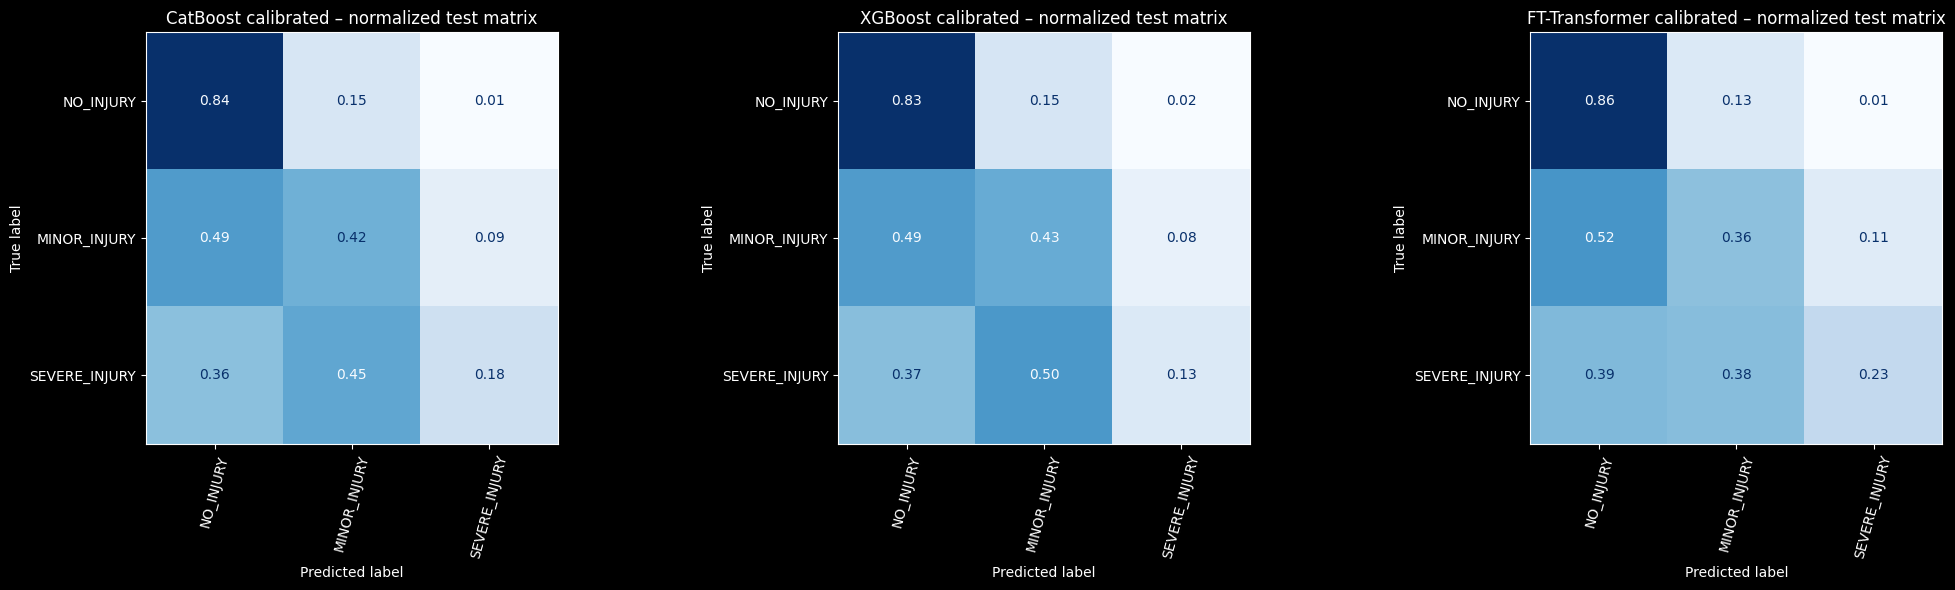

All models, predictions, reports, metrics, and plots were saved to: D:\Code\LZU-INFO442-Traffic-Accident-Severity-Prediction\M5\model_outputs


In [18]:
comparison = pd.DataFrame(metric_rows)
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
weight_search_results = pd.DataFrame(
    [
        {"model": model_name, "weight_alpha": trial["alpha"],
         "validation_macro_f1": trial["validation_macro_f1"], "training_seconds": trial["seconds"]}
        for model_name, trials in [
            ("CatBoost", catboost_trials),
            ("XGBoost", xgboost_trials),
            ("FT-Transformer", ft_trials),
        ]
        for trial in trials
    ]
)
weight_search_results.to_csv(OUTPUT_DIR / "weight_search_results.csv", index=False)

validation_comparison = (
    comparison[comparison["split"] == "validation"]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
test_comparison = (
    comparison[comparison["split"] == "test"]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
winner = validation_comparison.iloc[0]["model"]

print("Model selected by validation Macro F1:", winner)
display(weight_search_results.sort_values(["model", "validation_macro_f1"], ascending=[True, False]).round(4))
display(validation_comparison.round(4))
display(test_comparison.round(4))

plot_confusion_matrices(test_results)

summary = {
    "selection_metric": "validation_macro_f1",
    "selected_model": winner,
    "weight_alphas_searched": WEIGHT_ALPHAS,
    "calibration_multiplier_grid": CALIBRATION_MULTIPLIERS,
    "selected_tuning": {
        "CatBoost": {
            "weight_alpha": catboost_best["alpha"],
            "probability_multipliers": catboost_multipliers.tolist(),
        },
        "XGBoost": {
            "weight_alpha": xgboost_best["alpha"],
            "probability_multipliers": xgboost_multipliers.tolist(),
        },
        "FT-Transformer": {
            "weight_alpha": ft_best["alpha"],
            "focal_gamma": 2.0,
            "probability_multipliers": ft_multipliers.tolist(),
        },
    },
    "validation_metrics": validation_comparison.to_dict(orient="records"),
    "test_metrics": test_comparison.to_dict(orient="records"),
    "fast_run": FAST_RUN,
    "seed": SEED,
}
with (OUTPUT_DIR / "training_summary.json").open("w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=2)

print(f"All models, predictions, reports, metrics, and plots were saved to: {OUTPUT_DIR}")